# 前向欧拉法求解匀速直线运动

- [周详](xiangzhou@whu.edu.cn)
- 武汉大学 
- 2026年9月13日

匀速直线运动的加速度为零，其运动由如下一阶微分方程组描述：

$$
\frac{dx}{dt} = v, \qquad \frac{dv}{dt} = 0
$$

解析解为

$$
x(t) = x_0 + v_0\,t, \qquad v(t) = v_0
$$

**前向欧拉法（Forward Euler）** 用一阶差分近似导数，将时间离散为步长 $h$ 的网格：

$$
x_{n+1} = x_n + h\,v_n, \qquad v_{n+1} = v_n
$$

**运行之前，先把你的预测写下来**：

1. 前向欧拉格式 $x_{n+1} = x_n + h\,v_n,\; v_{n+1} = v_n$ 对匀速直线运动给出的数值解，与解析解相比有没有误差？
2. 总机械能 $E = \tfrac{1}{2}mv^2$ 在数值模拟中会漂移吗？

带着预测运行下面的代码，逐条对照。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 字体配置：按操作系统自动选择中文字体，
# 西文与数学公式用 Times New Roman 风格（STIX）
import platform
system = platform.system()
if system == 'Darwin':
    cn_font = 'Songti SC'
elif system == 'Windows':
    cn_font = 'SimSun'
else:  # Linux
    cn_font = 'Noto Serif CJK SC'

plt.rcParams['font.family'] = [cn_font, 'Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
def forward_euler(x0, v0, h, n_steps):
    """前向欧拉法求解 dx/dt = v, dv/dt = 0
    返回时间、位置、速度数组（长度 n_steps + 1）"""
    t = np.arange(n_steps + 1) * h
    x = np.empty(n_steps + 1)
    v = np.empty(n_steps + 1)
    x[0], v[0] = x0, v0
    for n in range(n_steps):
        x[n + 1] = x[n] + h * v[n]
        v[n + 1] = v[n]
    return t, x, v

位置最大相对误差 = 0.000e+00
速度最大相对误差 = 0.000e+00
总机械能 = 0.500 J（恒定），最大误差 = 0.000e+00 J
末位置 = 5.00 m（解析值 5.00 m）


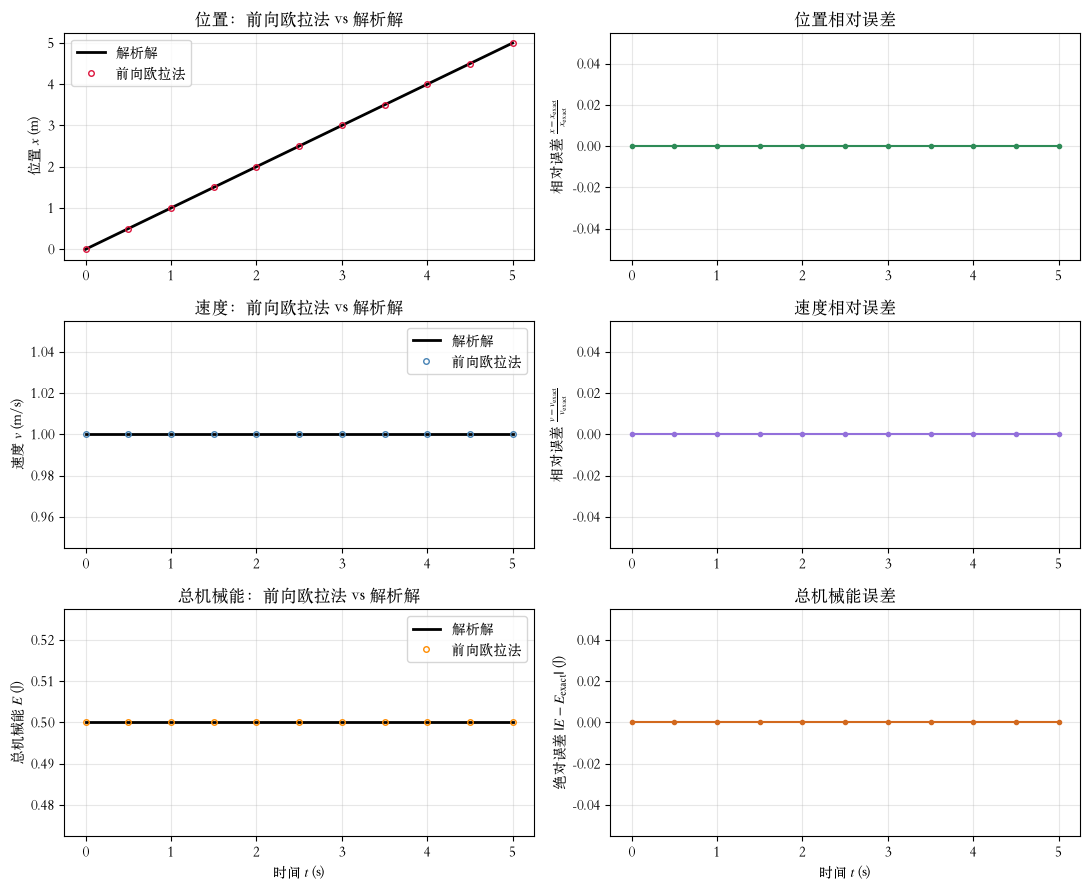

In [3]:
# 参数
x0, v0 = 0.0, 1.0   # 初始位置 (m)、初速度 (m/s)
m = 1.0             # 质量 (kg)
h = 0.5             # 时间步长 (s)
t_end = 5.0         # 总时间 (s)

t, x, v = forward_euler(x0, v0, h, int(t_end / h))
x_exact = x0 + v0 * t
v_exact = np.full_like(t, v0)

# 总机械能：自由粒子不受力，势能取零，E = 1/2 m v^2
E = 0.5 * m * v**2
E_exact = 0.5 * m * v_exact**2

# 位置相对误差（t=0 时 x_exact=0，该点误差恰为 0，直接取 0）
rel_err_x = np.zeros_like(x)
mask = x_exact != 0
rel_err_x[mask] = (x[mask] - x_exact[mask]) / x_exact[mask]

# 速度相对误差
rel_err_v = (v - v_exact) / v_exact

# 总能量误差（绝对误差）
E_err = np.abs(E - E_exact)

print(f'位置最大相对误差 = {rel_err_x.max():.3e}')
print(f'速度最大相对误差 = {rel_err_v.max():.3e}')
print(f'总机械能 = {E[0]:.3f} J（恒定），最大误差 = {E_err.max():.3e} J')
print(f'末位置 = {x[-1]:.2f} m（解析值 {x_exact[-1]:.2f} m）')

fig, axs = plt.subplots(3, 2, figsize=(11, 9))

# 左列：数值解 vs 解析解
ax = axs[0, 0]
ax.plot(t, x_exact, 'k-', lw=2, label='解析解')
ax.plot(t, x, 'o', ms=4, mfc='none', color='crimson', label='前向欧拉法')
ax.set_ylabel('位置 $x$ (m)')
ax.set_title('位置：前向欧拉法 vs 解析解')
ax.legend()
ax.grid(alpha=0.3)

ax = axs[1, 0]
ax.plot(t, v_exact, 'k-', lw=2, label='解析解')
ax.plot(t, v, 'o', ms=4, mfc='none', color='steelblue', label='前向欧拉法')
ax.set_ylabel('速度 $v$ (m/s)')
ax.set_title('速度：前向欧拉法 vs 解析解')
ax.legend()
ax.grid(alpha=0.3)

ax = axs[2, 0]
ax.plot(t, E_exact, 'k-', lw=2, label='解析解')
ax.plot(t, E, 'o', ms=4, mfc='none', color='darkorange', label='前向欧拉法')
ax.set_xlabel('时间 $t$ (s)')
ax.set_ylabel('总机械能 $E$ (J)')
ax.set_title('总机械能：前向欧拉法 vs 解析解')
ax.legend()
ax.grid(alpha=0.3)

# 右列：对应的误差
ax = axs[0, 1]
ax.plot(t, rel_err_x, '.-', color='seagreen')
ax.set_ylabel('相对误差 $\\frac{x - x_{\\mathrm{exact}}}{x_{\\mathrm{exact}}}$')
ax.set_title('位置相对误差')
ax.grid(alpha=0.3)

ax = axs[1, 1]
ax.plot(t, rel_err_v, '.-', color='mediumpurple')
ax.set_ylabel('相对误差 $\\frac{v - v_{\\mathrm{exact}}}{v_{\\mathrm{exact}}}$')
ax.set_title('速度相对误差')
ax.grid(alpha=0.3)

ax = axs[2, 1]
ax.plot(t, E_err, '.-', color='chocolate')
ax.set_xlabel('时间 $t$ (s)')
ax.set_ylabel('绝对误差 $|E - E_{\\mathrm{exact}}|$ (J)')
ax.set_title('总机械能误差')
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig('outputs/1_uniform_motion_euler_main.pdf', bbox_inches='tight')   # 矢量图导出
plt.show()

## 速度相空间矢量场

> **约定**：本系列把 $(x, v)$ 平面称为**速度相空间**——以速度 $v$ 代替动量 $p = mv$ 的状态空间；严格的分析力学“相空间”按 $(x, p)$ 定义，质量恒定时两者仅差坐标缩放。

匀速直线运动在速度相空间 $(x, v)$ 中的矢量场为

$$
\frac{dx}{dt} = v, \qquad \frac{dv}{dt} = 0
$$

箭头处处水平：位置以速度 $v$ 匀速漂移，速度本身永不改变。

几个要点：

- **平衡线 $v = 0$**：这条直线上处处 $\dot x = \dot v = 0$——与振子系统不同，匀速运动的平衡态不是孤立点，而是连续的一条线（任何位置都可以静止）。
- **轨道为水平线**：从任意初值出发，状态沿水平线匀速漂移；每条水平线同时是等能线（动能 $E = \tfrac{1}{2}mv^2$ 只依赖于 $v$）。
- **欧拉法精确的原因**：方向场均匀、轨道为直线，欧拉步进沿直线精确推进，数值轨道与解析轨道完全重合（误差仅为浮点精度）。

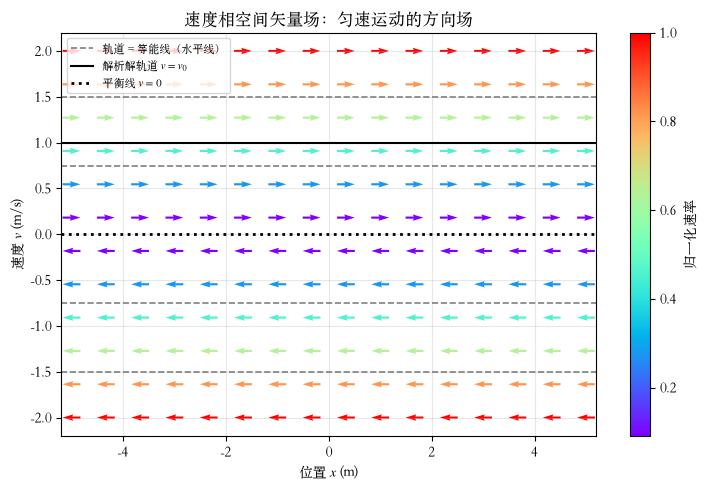

In [4]:
# 速度相空间矢量场：(dx/dt, dv/dt) = (v, 0)
# 箭头归一化为单位长度（只表示方向），颜色表示归一化速率
# 箭头处处水平：位置匀速漂移，速度永不改变
x_grid = np.linspace(-5.0, 5.0, 16)
v_grid = np.linspace(-2.0, 2.0, 12)
X, V = np.meshgrid(x_grid, v_grid)

U, W = V, np.zeros_like(X)
speed = np.abs(V)          # 速率 = |v|
speed_norm = speed / speed.max()

fig, ax = plt.subplots(figsize=(7.5, 5))
q = ax.quiver(X, V, U / speed, W / speed, speed_norm, cmap='rainbow',
              pivot='mid', scale=30, width=0.004)
cbar = fig.colorbar(q, ax=ax)
cbar.set_label('归一化速率')

# 轨道：水平线（每条同时是等能线，E = 1/2 m v^2 只依赖于 v）
for v_l in (-1.5, -0.75, 0.75, 1.5):
    ax.axhline(v_l, color='gray', ls='--', lw=1.2,
               label='轨道 = 等能线（水平线）' if v_l == -1.5 else None)

# 本算例的解析解轨道：水平线 v = v0
ax.axhline(v0, color='black', lw=1.5, label='解析解轨道 $v = v_0$')

# 平衡线：v = 0 上处处速度为零（连续分布的平衡态）
ax.axhline(0.0, color='black', ls=':', lw=2, label='平衡线 $v = 0$')

ax.set_xlabel('位置 $x$ (m)')
ax.set_ylabel('速度 $v$ (m/s)')
ax.set_xlim(-5.2, 5.2)
ax.set_ylim(-2.2, 2.2)
ax.set_title('速度相空间矢量场：匀速运动的方向场')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig('outputs/1_uniform_motion_euler_field.pdf', bbox_inches='tight')   # 矢量图导出
plt.show()

### 箭头的位置与颜色约定

- **位置**：每个箭头按 `pivot='mid'` 绘制——箭杆的**中点**恰落在它所描述的速度相空间格点 $(x_i,\,v_i)$ 上，并沿该点处的流方向对称延伸。读图时以箭杆中点为准。
- **颜色**：箭杆归一化为单位长度（只表示方向），矢量的**模长**改用颜色编码：按 $|(\dot x, \dot v)|\,/\,|(\dot x, \dot v)|_{\max}$ 以 rainbow 色条从蓝（慢）到红（快）着色。本例 $(\dot x, \dot v) = (v,\,0)$，模长 $=|v|$，故颜色只随纵坐标变化。

方向（箭头指向）+ 模长（颜色）合在一起，完整给出矢量场的信息。

## 结论与思考

**先对照运行结果，回答引言中的两个预测**（欧拉解有没有误差？能量会不会漂移？）

数值解与解析解的曲线完全重合，位置与速度的最大相对误差均为 $10^{-16}$ 量级（机器精度级别）。

原因：匀速运动中 $v$ 为常数，速度更新 $v_{n+1} = v_n$ 不改变速度，位移增量 $h\,v_0$ 与解析解的线性增长完全一致，方法本身不引入截断误差。

### 总机械能的稳定性

自由粒子不受力，势能取零，总机械能即动能 $E = \frac{1}{2}mv^2$。它在整个模拟过程中严格保持 $0.5$ J，误差恒为 $0$（精确到浮点运算）。

原因在于欧拉更新规则中速度满足 $v_{n+1} = v_n$：算法从不修改速度，因此能量被**精确守恒**。对于无外力的自由粒子，这是数值方法天然具备的良好性质——长时间模拟中能量不会漂移。

需要指出的是，这种能量稳定性只对自由运动成立。在速度随时间变化的系统中（如简谐振子、自由落体），前向欧拉法**不守恒能量**：每一步都会向系统人为注入能量，使 $E$ 随时间单调增长，最终导致数值发散（参见例 2 的能量漂移）。这正是分子动力学等领域偏爱能量稳定算法的重要原因。

对于速度随时间变化的问题，前向欧拉法还会产生 $O(h)$ 的截断误差，需要减小步长来控制（见后续各例）。